# Step 2 / Phase 1 — EDA & Precheck (Phase 0)

**Bài toán**: dự đoán hướng biến động tích lũy giá TCB (HOSE) đa horizon $k\in\{1,5,10,20\}$.

Notebook này là **Bước 2** trong pipeline xử lý dữ liệu (xem `data.md`). Mục tiêu: *nhìn kỹ dữ liệu thô để lấy bằng chứng cho các quyết định ở Bước 3–5, nhưng tuyệt đối không sửa dữ liệu.*

Nguyên tắc:
- **Read-only**: chỉ đọc `data/raw/`, chỉ ghi hình vào `reports/eda_phase0/figures/`. Không đụng `data/raw/` hay `data/processed/`. Có tính tạm log-return/nhãn *chỉ để xem* rồi bỏ.
- **Ranh giới pre-registration**: check *ảnh hưởng thiết kế* (phân phối nhãn, ADF, ties) báo cáo trên **Phase-0 window** `2018-06-04 → 2022-06-30`; check *chất lượng thuần* (jump giá, gap lịch, missing/lệch lịch) chạy **toàn chuỗi**.
- **EDA ở đây để *xác nhận*, không phải *khám phá***: có hình mô tả (phân phối, volatility, coverage) nhưng **không** vẽ quan hệ feature–nhãn — phần đó để hậu kiểm sau model (SHAP, Phase 6).

Sản phẩm chính nằm ở **mục cuối — "Tham số khóa cho Bước 3–5"** (tự sinh từ số liệu).


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller


def find_root(start: Path) -> Path:
    "Dò ngược cây thư mục cho tới khi thấy data/raw (chạy được dù notebook ở notebooks/)."
    for p in [start, *start.parents]:
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError("Không tìm thấy data/raw tính từ cwd hiện tại.")


ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))                       # để import được src/
from src.data.validation import (                    # tái dùng validator của Step 1
    check_monotonic_dates, check_hose_calendar_gap, check_abnormal_returns,
)

RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "eda_phase0" / "figures"
FIG.mkdir(parents=True, exist_ok=True)              # chỉ tạo thư mục report (không phải data)

START      = pd.Timestamp("2018-06-04")             # ngày niêm yết TCB
PHASE0_END = pd.Timestamp("2022-06-30")             # ranh giới pre-registration
HORIZONS   = [1, 5, 10, 20]
pd.set_option("display.width", 130)
print("ROOT =", ROOT)


def phase0(df: pd.DataFrame, date_col="date") -> pd.DataFrame:
    "Lát cắt Phase-0 window cho các check ảnh hưởng thiết kế."
    m = (df[date_col] >= START) & (df[date_col] <= PHASE0_END)
    return df.loc[m].copy()


def adf_report(x, label: str) -> float:
    "ADF test, in kết luận, trả p-value. H0: có unit root (non-stationary)."
    x = pd.Series(x).dropna()
    stat, pval, lags, nobs, crit, _ = adfuller(x, autolag="AIC")
    verdict = "stationary" if pval < 0.05 else "NON-stationary"
    print(f"{label:26s} ADF={stat:8.3f}  p={pval:7.4f}  lags={lags:2d}  n={nobs:5d}  => {verdict} @5%")
    return pval

ROOT = c:\Users\BKAI\ducluong\DrugOptimization\Data-Science


In [2]:
# Đọc 6 nguồn raw + overview nhanh
def load(name): return pd.read_parquet(RAW / f"{name}.parquet")

price, vnindex, usdvnd = load("tcb_price"), load("vnindex"), load("usdvnd")
cpi, gdp, fund = load("cpi"), load("gdp"), load("tcb_fundamentals")

for nm, df in [("tcb_price",price),("vnindex",vnindex),("usdvnd",usdvnd),
               ("cpi",cpi),("gdp",gdp),("tcb_fundamentals",fund)]:
    print(f"{nm:18s} rows={len(df):5d}  cols={list(df.columns)}")

tcb_price          rows= 1994  cols=['date', 'open', 'high', 'low', 'close', 'volume', 'fetched_at']
vnindex            rows= 2086  cols=['date', 'open', 'high', 'low', 'close', 'volume', 'fetched_at']
usdvnd             rows= 2078  cols=['date', 'open', 'high', 'low', 'close', 'volume', 'fetched_at']
cpi                rows=  109  cols=['reference_period', 'cpi_index', 'release_date', 'fetched_at']
gdp                rows=   37  cols=['reference_period', 'nominal_gdp_vnd_bil', 'release_date', 'fetched_at']
tcb_fundamentals   rows=   33  cols=['reference_period', 'release_date', 'total_assets_vnd_bil', 'equity_vnd_bil', 'net_interest_income_vnd_bil', 'interest_earning_assets_vnd_bil', 'npl_ratio_pct', 'credit_balance_vnd_bil', 'eps_ttm', 'nim_pct', 'fetched_at']


## Check 1 — Adjusted close có đáng tin? *(toàn chuỗi)*

Câu hỏi: chuỗi giá điều chỉnh có jump bất thường không, đặc biệt quanh **chia cổ tức cổ phiếu 1:1 năm 2024**?
→ Quyết định: có dùng giá thẳng cho L1/L2/nhãn được không, hay cần xử lý thêm.

Tái dùng đúng 3 validator của Step 1 (`check_monotonic_dates`, `check_hose_calendar_gap`, `check_abnormal_returns`).

In [3]:
# (a) Chạy lại validator của Step 1
for fn in (check_monotonic_dates, check_hose_calendar_gap, check_abnormal_returns):
    print(fn(price, "tcb_price").summary()); print("-"*70)

# (b) Đếm phiên |log-return| > 15% (biến tạm, chỉ để chẩn đoán)
p = price.sort_values("date").reset_index(drop=True)
p["logret"] = np.log(p["close"] / p["close"].shift(1))
n_abnormal = int((p["logret"].abs() > 0.15).sum())
print(f"\nSố phiên |log-return| > 15%: {n_abnormal}")
print("\nTop 5 |log-return| để spot-check:")
top = p.reindex(p["logret"].abs().sort_values(ascending=False).index)
print(top[["date","close","logret"]].head().to_string(index=False))

[tcb_price] rows=1994 range=(2018-06-04 → 2026-05-28) warnings=0 errors=0
----------------------------------------------------------------------
[tcb_price] rows=1994 range=(2018-06-04 → 2026-05-28) warnings=0 errors=0
----------------------------------------------------------------------
[tcb_price] rows=1994 range=(2018-06-04 → 2026-05-28) warnings=0 errors=0
----------------------------------------------------------------------

Số phiên |log-return| > 15%: 0

Top 5 |log-return| để spot-check:
      date  close    logret
2020-03-12   8.30 -0.073161
2022-10-11  11.10 -0.072949
2022-10-07  12.61 -0.072634
2022-10-24   9.85 -0.072439
2025-04-03  24.76 -0.072433


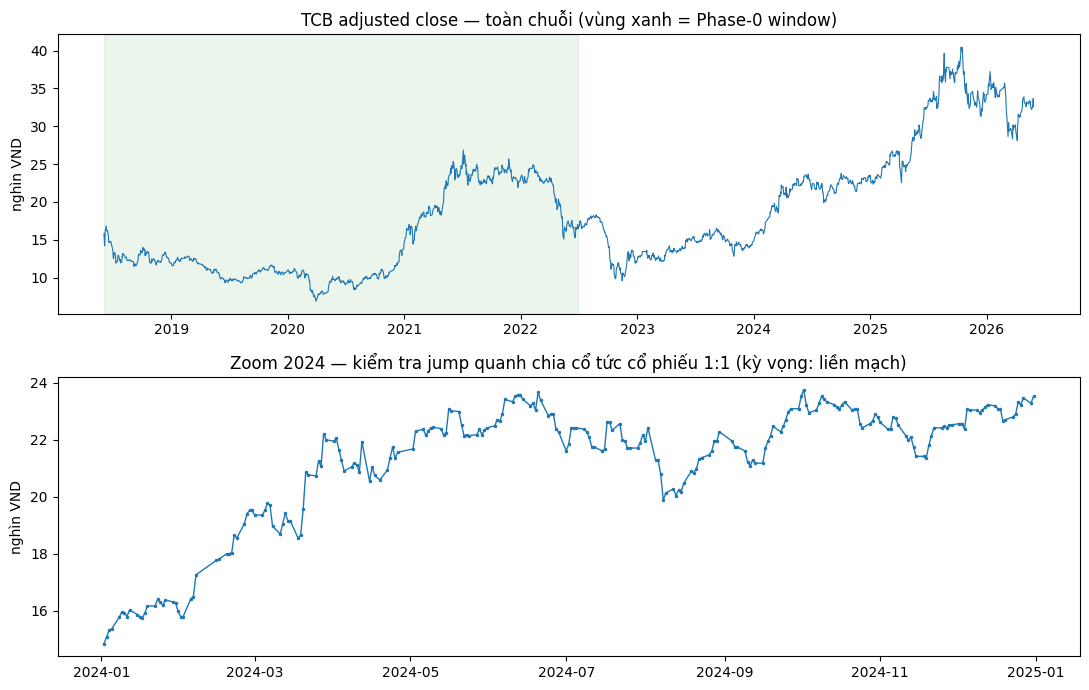

In [4]:
# (c) Trực quan: toàn chuỗi (vùng xanh = Phase-0) + zoom 2024
fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(p["date"], p["close"], lw=0.8)
ax[0].axvspan(START, PHASE0_END, alpha=0.08, color="green")
ax[0].set_title("TCB adjusted close — toàn chuỗi (vùng xanh = Phase-0 window)")
ax[0].set_ylabel("nghìn VND")

m24 = (p["date"] >= "2024-01-01") & (p["date"] <= "2024-12-31")
ax[1].plot(p.loc[m24, "date"], p.loc[m24, "close"], lw=1.0, marker=".", ms=3)
ax[1].set_title("Zoom 2024 — kiểm tra jump quanh chia cổ tức cổ phiếu 1:1 (kỳ vọng: liền mạch)")
ax[1].set_ylabel("nghìn VND")
fig.tight_layout(); fig.savefig(FIG / "01_adjusted_close.png", dpi=110); plt.show()

### Check 1b — Mô tả chuỗi return (descriptive, an toàn)

Hình mô tả *bản chất chuỗi return* — không chạm quan hệ feature–nhãn nên không vi phạm ranh giới confirmatory.
→ Mục đích: thấy **fat tail** (lý giải vì sao dự đoán *hướng* chứ không *biên độ*) và **các regime volatility** (bối cảnh cho RQ1.3).

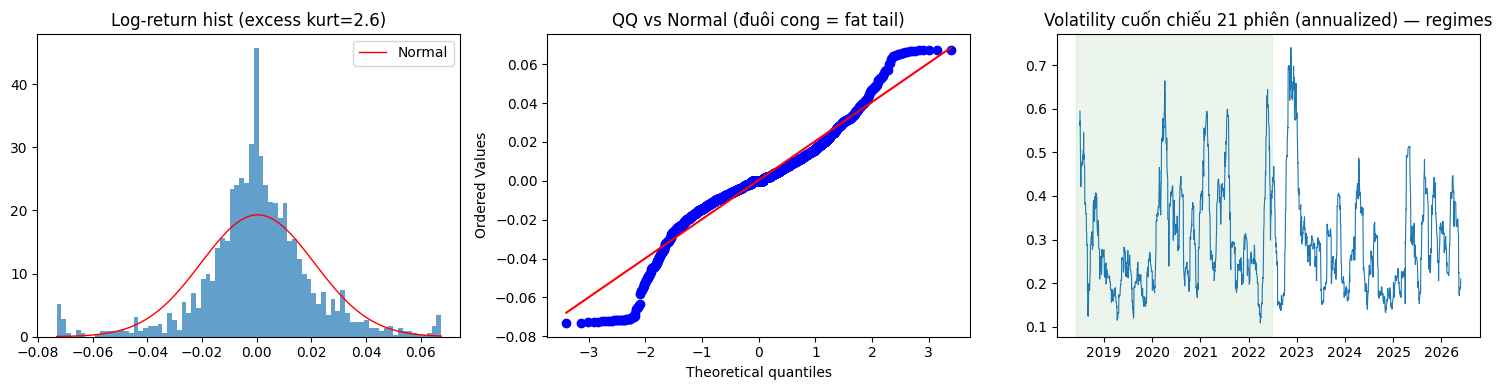

Log-return: mean=0.00036  std=0.02068  skew=-0.31  excess_kurt=2.56


In [5]:
r = p["logret"].dropna()
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) histogram + overlay Normal
ax[0].hist(r, bins=80, density=True, alpha=0.7)
xs = np.linspace(r.min(), r.max(), 200)
ax[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), "r-", lw=1, label="Normal")
ax[0].set_title(f"Log-return hist (excess kurt={stats.kurtosis(r):.1f})"); ax[0].legend()

# (b) QQ-plot vs Normal
stats.probplot(r.to_numpy(), dist="norm", plot=ax[1])
ax[1].set_title("QQ vs Normal (đuôi cong = fat tail)")

# (c) volatility cuốn chiếu 21 phiên (annualized) — dùng cột có NaN để khớp trục date
vol = p["logret"].rolling(21).std() * np.sqrt(252)
ax[2].plot(p["date"], vol, lw=0.8)
ax[2].axvspan(START, PHASE0_END, alpha=0.08, color="green")
ax[2].set_title("Volatility cuốn chiếu 21 phiên (annualized) — regimes")
fig.tight_layout(); fig.savefig(FIG / "02_return_dist_vol.png", dpi=110); plt.show()

print(f"Log-return: mean={r.mean():.5f}  std={r.std():.5f}  "
      f"skew={stats.skew(r):.2f}  excess_kurt={stats.kurtosis(r):.2f}")

## Check 2 — Nhãn lệch lớp đến đâu? *(Phase-0 window)*

Câu hỏi: tỷ lệ +1 / −1 ở mỗi $k$ (theo quy ước $P_{t+k}=P_t \Rightarrow y=+1$).
→ Quyết định: xác nhận **chấp nhận imbalance** (không SMOTE) và dùng metric phụ BalAcc/MCC.

In [6]:
def label_distribution(df: pd.DataFrame) -> pd.DataFrame:
    P = df.sort_values("date")["close"].to_numpy()
    rows = []
    for k in HORIZONS:
        diff = P[k:] - P[:-k]
        up, down, tie = int((diff > 0).sum()), int((diff < 0).sum()), int((diff == 0).sum())
        n = up + down + tie
        pos = up + tie                       # quy ước tie -> +1
        rows.append({"k": k, "n": n, "pos(+1)": pos, "neg(-1)": down,
                     "pct_up_%": round(100*pos/n, 2), "ties": tie})
    return pd.DataFrame(rows)

dist = label_distribution(phase0(price))
print("Phân phối nhãn trên Phase-0 window:")
print(dist.to_string(index=False))

Phân phối nhãn trên Phase-0 window:
 k    n  pos(+1)  neg(-1)  pct_up_%  ties
 1 1020      555      465     54.41    81
 5 1016      536      480     52.76    26
10 1011      517      494     51.14     9
20 1001      511      490     51.05     5


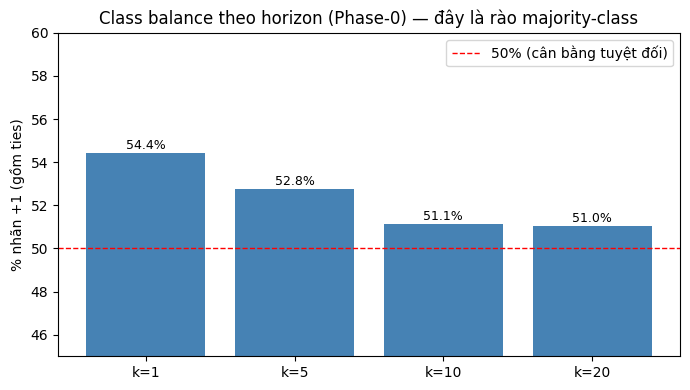

In [7]:
# Trực quan class-balance theo k — % nhãn +1 vs mốc 50% (= rào của baseline majority)
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(dist))
ax.bar(x, dist["pct_up_%"], color="steelblue")
ax.axhline(50, color="red", ls="--", lw=1, label="50% (cân bằng tuyệt đối)")
ax.set_ylim(45, 60)
for i, v in enumerate(dist["pct_up_%"]):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"k={k}" for k in dist["k"]])
ax.set_ylabel("% nhãn +1 (gồm ties)")
ax.set_title("Class balance theo horizon (Phase-0) — đây là rào majority-class")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "03_class_balance.png", dpi=110); plt.show()

## Check 3 — Tính dừng (ADF) *(Phase-0 window)*

Câu hỏi: $P_t$ có **non-stationary** (kỳ vọng có) và log-return có **stationary** (kỳ vọng có) không?
→ Quyết định: xác nhận lý do **loại giá thô khỏi L1**, dùng log-return làm cơ sở.

Đây là *xác nhận giả định đã ghi trong research_design*, không phải phát hiện mới.

In [8]:
p0 = phase0(price).sort_values("date").reset_index(drop=True)
adf_price_p = adf_report(p0["close"],                  "P_t (giá thô)")        # kỳ vọng NON-stationary
adf_ret_p   = adf_report(np.log(p0["close"]).diff(),   "log-return r_t")       # kỳ vọng stationary

P_t (giá thô)              ADF=  -0.963  p= 0.7665  lags= 0  n= 1020  => NON-stationary @5%
log-return r_t             ADF= -29.525  p= 0.0000  lags= 0  n= 1019  => stationary @5%


## Check 4 — Đếm ties $P_{t+k}=P_t$ *(toàn chuỗi + Phase-0)*

Câu hỏi: quy ước gán $+1$ cho ties chạm bao nhiêu dòng?
→ Quyết định: giá rời rạc theo bước giá (tick) nên ties **không** "gần 0" như giả định ban đầu; cần đính chính + flag.

In [9]:
def count_ties(df: pd.DataFrame) -> dict:
    P = df.sort_values("date")["close"].to_numpy()
    return {k: int((P[k:] - P[:-k] == 0).sum()) for k in HORIZONS}

ties_full = count_ties(price)
ties_p0   = count_ties(phase0(price))
print("Ties P[t+k]==P[t] (toàn chuỗi):", ties_full)
print("Ties P[t+k]==P[t] (Phase-0)   :", ties_p0)
# Tỷ lệ ties trên tổng nhãn từng k (toàn chuỗi)
N = len(price)
print("Tie-rate (toàn chuỗi):", {k: f"{100*ties_full[k]/(N-k):.1f}%" for k in HORIZONS})

Ties P[t+k]==P[t] (toàn chuỗi): {1: 155, 5: 46, 10: 21, 20: 11}
Ties P[t+k]==P[t] (Phase-0)   : {1: 81, 5: 26, 10: 9, 20: 5}
Tie-rate (toàn chuỗi): {1: '7.8%', 5: '2.3%', 10: '1.1%', 20: '0.6%'}


## Check 5 — Lệch lịch & missing giữa các nguồn *(toàn chuỗi)*

Câu hỏi: FX (24/5) lệch lịch HOSE bao nhiêu? CPI/GDP/fundamentals thưa & trễ release thế nào? Có NaN ở đâu (đặc biệt L4)?
→ Quyết định: cách **reindex/forward-fill FX** (Bước 3), **warmup as-of** (Bước 4), và **xử lý 2 quý thiếu NPL/NIM**.

In [10]:
# (a) FX vs lịch HOSE (HOSE = tập ngày của tcb_price)
hose, fx = set(price["date"]), set(usdvnd["date"])
fx_missing_on_hose = len(hose - fx)        # ngày HOSE giao dịch mà FX thiếu -> cần ffill
print(f"HOSE phiên = {len(hose)} | FX phiên = {len(fx)}")
print(f"  Ngày HOSE giao dịch nhưng FX thiếu : {fx_missing_on_hose}")
print(f"  Ngày FX có nhưng HOSE nghỉ         : {len(fx - hose)}")

# (b) Nguồn chậm: độ thưa + độ trễ release
print("\nNguồn chậm (số kỳ + khoảng + độ trễ release):")
for nm, df in [("cpi",cpi),("gdp",gdp),("tcb_fundamentals",fund)]:
    rp = pd.to_datetime(df["reference_period"]); rd = pd.to_datetime(df["release_date"])
    lag = (rd - rp).dt.days
    print(f"  {nm:18s} n={len(df):3d}  ref=({rp.min().date()} → {rp.max().date()})  "
          f"release_lag median={int(lag.median())}d (min={int(lag.min())}, max={int(lag.max())})")

# (c) NaN trong fundamentals (L4 có cột nullable + warmup YoY đầu chuỗi)
print("\nNaN theo cột — tcb_fundamentals:")
print(fund.isna().sum().to_string())

# (d) SOI: 2 quý nào thiếu NPL / NIM? -> quyết định ffill vs warmup-drop ở Bước 4/5
miss = fund[fund["npl_ratio_pct"].isna() | fund["nim_pct"].isna()]
print("\nQuý thiếu NPL hoặc NIM:")
print(miss[["reference_period","npl_ratio_pct","nim_pct"]].to_string(index=False))

HOSE phiên = 1994 | FX phiên = 2078
  Ngày HOSE giao dịch nhưng FX thiếu : 239
  Ngày FX có nhưng HOSE nghỉ         : 323

Nguồn chậm (số kỳ + khoảng + độ trễ release):
  cpi                n=109  ref=(2017-03-31 → 2026-03-31)  release_lag median=6d (min=6, max=6)
  gdp                n= 37  ref=(2017-03-31 → 2026-03-31)  release_lag median=30d (min=30, max=30)
  tcb_fundamentals   n= 33  ref=(2018-03-31 → 2026-03-31)  release_lag median=45d (min=45, max=45)

NaN theo cột — tcb_fundamentals:
reference_period                    0
release_date                        0
total_assets_vnd_bil                0
equity_vnd_bil                      0
net_interest_income_vnd_bil         0
interest_earning_assets_vnd_bil    33
npl_ratio_pct                       2
credit_balance_vnd_bil              0
eps_ttm                             0
nim_pct                             2
fetched_at                          0

Quý thiếu NPL hoặc NIM:
reference_period  npl_ratio_pct  nim_pct
      2018-03-31   

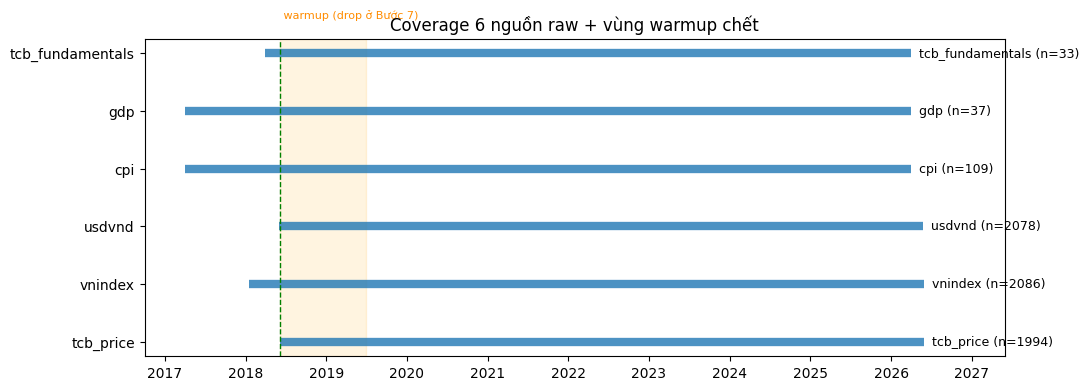

In [11]:
# (e) Coverage timeline 6 nguồn + vùng warmup chết
sources = [
    ("tcb_price",        price["date"]),
    ("vnindex",          vnindex["date"]),
    ("usdvnd",           usdvnd["date"]),
    ("cpi",              cpi["reference_period"]),
    ("gdp",              gdp["reference_period"]),
    ("tcb_fundamentals", fund["reference_period"]),
]
fig, ax = plt.subplots(figsize=(11, 4))
for i, (nm, s) in enumerate(sources):
    s = pd.to_datetime(s)
    ax.hlines(i, s.min(), s.max(), lw=6, alpha=0.8)
    ax.text(s.max(), i, f"  {nm} (n={len(s)})", va="center", fontsize=9)
ax.axvline(START, color="green", ls="--", lw=1)
warmup_end = pd.Timestamp("2019-06-30")   # ~252 phiên technical + 4 quý YoY
ax.axvspan(START, warmup_end, alpha=0.12, color="orange")
ax.text(START, len(sources) - 0.4, " warmup (drop ở Bước 7)", color="darkorange", fontsize=8)
ax.set_yticks(range(len(sources))); ax.set_yticklabels([nm for nm, _ in sources])
ax.set_xlim(pd.Timestamp("2016-10-01"), pd.Timestamp("2027-06-01"))
ax.set_title("Coverage 6 nguồn raw + vùng warmup chết")
fig.tight_layout(); fig.savefig(FIG / "04_coverage_timeline.png", dpi=110); plt.show()

## Tham số khóa cho Bước 3–5 *(sản phẩm chính, tự sinh)*

Ô dưới tổng hợp các con số ở trên thành **quyết định cụ thể** để khóa cho các bước sau. Đây là đầu ra duy nhất của EDA — không có file dữ liệu mới được tạo.

In [12]:
print("="*72)
print("THAM SỐ KHÓA CHO BƯỚC 3–5  (sinh từ kết quả EDA Phase 0)")
print("="*72)

ok_close = (n_abnormal == 0)
print(f"\n[1] Adjusted close:")
print(f"    - |log-return|>15%: {n_abnormal} phiên -> {'OK, dùng giá thẳng cho L1/L2/nhãn.' if ok_close else 'CẦN INSPECT thủ công trước khi dùng.'}")
print(f"    - Hình 01 zoom-2024: xác nhận không có jump quanh chia cổ tức 1:1.")

print(f"\n[2] Class imbalance (Phase-0, quy ước tie->+1):")
for _, r_ in dist.iterrows():
    print(f"    - k={int(r_['k']):2d}: {r_['pct_up_%']:.1f}% nhãn +1  (n={int(r_['n'])})")
print(f"    => Chấp nhận imbalance theo phân phối tự nhiên, KHÔNG SMOTE; báo cáo BalAcc/MCC phụ.")

print(f"\n[3] Stationarity (Phase-0):")
print(f"    - P_t: p={adf_price_p:.4f} -> {'NON-stationary (đúng kỳ vọng) => LOẠI giá thô khỏi L1.' if adf_price_p>=0.05 else 'BẤT NGỜ stationary => ghi nhận, KHÔNG đổi feature.'}")
print(f"    - log-return: p={adf_ret_p:.4f} -> {'stationary (đúng kỳ vọng) => dùng làm cơ sở L1.' if adf_ret_p<0.05 else 'BẤT NGỜ non-stationary => ghi nhận.'}")

k1 = dist[dist["k"] == 1].iloc[0]
strict_up = 100 * (k1["pos(+1)"] - k1["ties"]) / k1["n"]
print(f"\n[4] Ties (PHÁT HIỆN): toàn chuỗi {ties_full}")
print(f"    - k=1: ties={int(k1['ties'])} (~{100*k1['ties']/k1['n']:.1f}% Phase-0) — KHÔNG 'gần 0' (giá rời rạc theo tick).")
print(f"    - Strict-up k=1 chỉ {strict_up:.1f}% (vs {k1['pct_up_%']:.1f}% sau khi gán ties->+1).")
print(f"    => GIỮ quy ước +1: DM so trên chênh lệch -> bất biến với quy ước; baseline majority mạnh lên -> bảo thủ.")
print(f"    => ĐÍNH CHÍNH research_design: thay 'ties xác suất gần 0' bằng tie-rate thực; báo cáo tie-rate kèm accuracy ở k nhỏ.")

print(f"\n[5] Căn lịch & warmup:")
print(f"    - FX thiếu {fx_missing_on_hose} ngày HOSE => Bước 3: reindex USD/VND về lịch HOSE rồi forward-fill MỨC tỷ giá (tính %change sau).")
print(f"    - L3/L4 dùng release_date để as-of join (Bước 4); forward-fill giữa 2 lần công bố.")
print(f"    - Warmup: momentum ~252 phiên + L4 YoY 4 quý => vùng dùng được bắt đầu ~giữa 2019; chốt cắt ở Bước 7.")

miss_q = [pd.to_datetime(d).date().isoformat() for d in miss["reference_period"]]
print(f"\n[6] L4 fundamentals:")
print(f"    - interest_earning_assets: 33/33 NaN (vnstock không có) — chỉ là fallback NIM, NIM lấy từ nim_pct => cột chết, ghi chú.")
print(f"    - Thiếu NPL/NIM ở {len(miss)} quý: {miss_q}")
print(f"      => quý ≤2019 rơi vào warmup (drop tự nhiên); quý giữa chuỗi thì forward-fill từ quý trước (Bước 4/5).")
print("="*72)

THAM SỐ KHÓA CHO BƯỚC 3–5  (sinh từ kết quả EDA Phase 0)

[1] Adjusted close:
    - |log-return|>15%: 0 phiên -> OK, dùng giá thẳng cho L1/L2/nhãn.
    - Hình 01 zoom-2024: xác nhận không có jump quanh chia cổ tức 1:1.

[2] Class imbalance (Phase-0, quy ước tie->+1):
    - k= 1: 54.4% nhãn +1  (n=1020)
    - k= 5: 52.8% nhãn +1  (n=1016)
    - k=10: 51.1% nhãn +1  (n=1011)
    - k=20: 51.0% nhãn +1  (n=1001)
    => Chấp nhận imbalance theo phân phối tự nhiên, KHÔNG SMOTE; báo cáo BalAcc/MCC phụ.

[3] Stationarity (Phase-0):
    - P_t: p=0.7665 -> NON-stationary (đúng kỳ vọng) => LOẠI giá thô khỏi L1.
    - log-return: p=0.0000 -> stationary (đúng kỳ vọng) => dùng làm cơ sở L1.

[4] Ties (PHÁT HIỆN): toàn chuỗi {1: 155, 5: 46, 10: 21, 20: 11}
    - k=1: ties=81 (~7.9% Phase-0) — KHÔNG 'gần 0' (giá rời rạc theo tick).
    - Strict-up k=1 chỉ 46.5% (vs 54.4% sau khi gán ties->+1).
    => GIỮ quy ước +1: DM so trên chênh lệch -> bất biến với quy ước; baseline majority mạnh lên -> bảo thủ.
